## Семинар: "Методы оптимизации"

In [ ]:
from functools import partial

import numpy as np
import torch
from tqdm.auto import tqdm
from torch import nn
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm
from matplotlib import animation
from mpl_toolkits import mplot3d
from matplotlib.gridspec import GridSpec
from torchvision import datasets, transforms
from IPython.display import HTML
%matplotlib inline
plt.rc('animation', html='html5')

In [ ]:
!pip install -U torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install -U triton

Looking in indexes: https://download.pytorch.org/whl/cu121


In [ ]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.version.cuda)

2.8.0+cu126
True
12.6


In [ ]:
!nvidia-smi

Tue Sep 30 09:05:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   56C    P8             11W /   70W |       2MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

На этом семинаре мы попробуем реализовать и сравнить различные методы оптимизации: SGD, Momentum, NAG, Adagrad, RMSProp, AdaDelta.

### Реализация методов

Для всех экспериментов подберите параметры так, чтобы метод сошелся к ближайшему локальному минимуму. Все методы следует запускать из одной и той же точки.

In [ ]:
# https://github.com/dzlab/deepprojects/blob/master/visualization/Optimizers_in_Action.ipynb

def grid_samples(center=[0, 0], offset=5, size=100):
    range1 = np.linspace(center[0]-offset, center[0]+offset, size)
    range2 = np.linspace(center[1]-offset, center[1]+offset, size)
    return torch.from_numpy(np.stack(np.meshgrid(range1, range2))).float()


def mse(y, y_hat):
    return ((y - y_hat) ** 2).mean(axis=-1)


def msre(y, y_hat):
    return ((y - y_hat) ** 2).mean(axis=-1).sqrt()


def mae(y, y_hat):
    return ((y - y_hat).abs()).mean(axis=-1)


class LossAnimator:
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.size = len(X)

    def loss_func(self, W, loss):
        shape = W.shape
        return loss((self.X @ W.view(shape[0], -1)).T, self.y).view(shape[1:])

    def plot_loss_funcs(self, weights, fcts, titles, view=(20, 50)):
        num_fcts = len(fcts)
        fig = plt.figure(figsize=(7 * num_fcts,7))
        for i in range(num_fcts):
            loss = self.loss_func(weights, loss=fcts[i])
            ax = fig.add_subplot(1, num_fcts, i+1, projection='3d')
            ax.plot_surface(*weights, loss, cmap='viridis')
            ax.set_xlabel('w0'); ax.set_ylabel('w1'); ax.set_zlabel('Loss')
            ax.set_title(titles[i])
            ax.view_init(*view)

    def _init_animation(self, epochs, train_data):
        self.train_data = train_data
        self.epochs = epochs
        self.nmethods = len(train_data)

        weights = grid_samples(offset=5)

        max_loss = max([data['losses'].max() for data in train_data.values()])
        loss_curve = self.loss_func(weights, loss=mse)
        colors = cm.rainbow(np.linspace(0, 1, self.nmethods))


        self.fig = plt.figure(figsize=(14, 8))
        self.gs = GridSpec(2, 2, width_ratios=[1, 2.5])

        self.ax0 = self.fig.add_subplot(self.gs[0,0])
        self.lines0 = {
            name: self.ax0.plot([], [], c=c, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax0.scatter(self.X[:,0], self.y, c='orange', label='Ground truth')
        self.ax0.set_ylim(self.y.min(), self.y.max())
        self.ax0.set_title('Ground truth & Model', fontsize=16)
        self.ax0.legend(loc='lower right')

        self.ax1 = self.fig.add_subplot(self.gs[:,1], projection='3d')
        self.ax1.plot_surface(*weights, loss_curve-0.5, cmap='viridis', alpha=0.8)
        self.ax1.view_init(50, 70)
        self.lines1 = {
            name: self.ax1.plot3D([], [], [], c=c, marker='o', alpha=0.9, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax1.set_title('Loss', fontsize=16, pad=20)
        self.ax1.set_xlabel('w0')
        self.ax1.set_ylabel('w1')
        self.ax1.set_zlabel('Loss')
        self.ax1.legend()

        self.ax2 = self.fig.add_subplot(self.gs[1,0])
        self.lines2 = {
            name: self.ax2.plot([], [], c=c, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax2.set_title('Loss', fontsize=16)
        self.ax2.set_ylabel('loss')
        self.ax2.set_ybound(0, max_loss)
        self.ax2.set_xlim(0, epochs)
        self.ax2.legend(loc='center right')

        self.fig.tight_layout()
        self.fig.subplots_adjust(top=0.85)

        plt.close()

        return self.fig

    def _animate(self, i):
        steps = np.arange(i+1)
        left = max(0, i-20)
        for name, data in self.train_data.items():
            # plot ground truth & model
            self.lines0[name].set_data(self.X[:, 0], self.X @ data['weights'][i])

            # plot loss (output of the sampling)
            self.lines1[name].set_data(data['weights'][left:i+1, 0], data['weights'][left:i+1, 1])
            self.lines1[name].set_3d_properties(data['losses'][left:i+1])

            self.lines2[name].set_data(steps, data['losses'][:i+1])

        self.fig.suptitle(f'Epoch: {i}/{self.epochs}', fontsize=22)

    def animate(self, epochs, train_data, step_skip=1):
        self._init_animation(epochs, train_data)
        anim = animation.FuncAnimation(self.fig, self._animate, frames=range(0, epochs, step_skip), interval=100 * step_skip)
        return HTML(anim.to_html5_video())

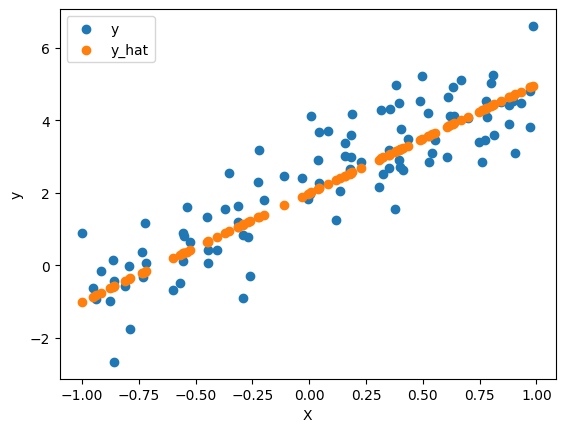

In [ ]:
size = 100
X = torch.ones(size, 2)
X[:, 0].uniform_(-1., 1)

y_hat = 3 * X[:, 0] + 2
y = y_hat + torch.randn(size)

loss_animator = LossAnimator(X, y)

plt.scatter(loss_animator.X[:,0], loss_animator.y, label='y');
plt.scatter(loss_animator.X[:,0], y_hat, label='y_hat');
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

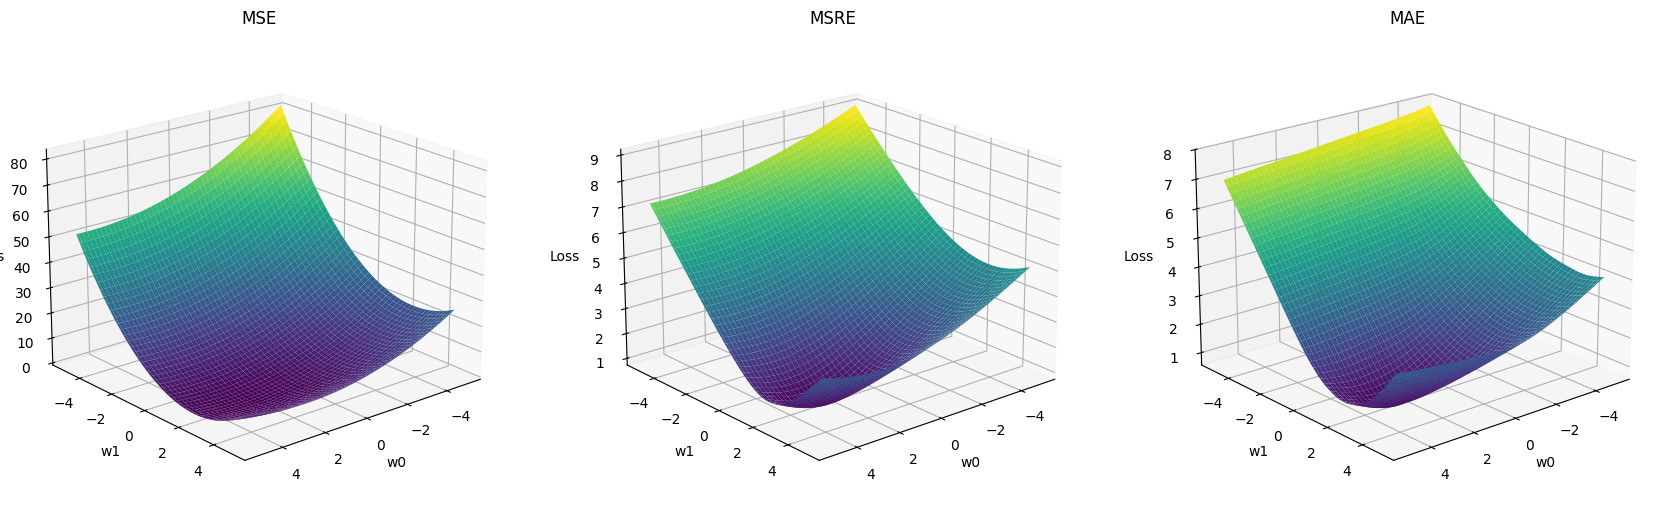

In [ ]:
weights = grid_samples()
loss_animator.plot_loss_funcs(weights, [mse, msre, mae], ['MSE', 'MSRE', 'MAE'])

In [ ]:
class Optimizer:
    def __init__(self, params):
        self.params = list(params)

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.detach_()
                param.grad.zero_()

    def pre_step(self):
        pass

    def step(self):
        pass

    def update_param(self, p):
        raise NotImplementedError()


In [ ]:
def optimize_function(fn, optim, optim_args, start_point, num_iter = 50):
    weigths = nn.Parameter(torch.FloatTensor(start_point), requires_grad=True)

    optim = optim(params=[weigths], **optim_args)
    points = []
    losses = []
    for i in range(num_iter):
        if hasattr(optim, 'pre_step'):
            optim.pre_step()
        loss = fn(weigths)
        points.append(weigths.data.detach().clone())
        losses.append(loss.item())
        loss.backward()
        optim.step()
        optim.zero_grad()
    points = torch.stack(points, axis=0)
    losses = torch.FloatTensor(losses)
    return points, losses


In [ ]:
def compare_optimizers(
    loss_animator,
    fn,
    optim_list,
    start_point,
    num_iter = 50,
    step_skip = 1
):
    data = {}
    loss_func = partial(loss_animator.loss_func, loss=fn)
    for name, optim, args in tqdm(optim_list):
        points, losses = optimize_function(loss_func, optim, args, start_point, num_iter)
        data[name] = {
            'weights': points,
            'losses': losses,
        }

    return loss_animator.animate(num_iter, data, step_skip=step_skip)

#### SGD
$$\theta_t = \theta_{t-1} - \eta \sum_{i_1, ..., i_k} \nabla_{\theta} J_{i} (\theta_{t-1})$$

In [ ]:
class SGD(Optimizer):
    def __init__(self, params, lr=1e-2):
        super().__init__(params)
        self.lr = lr

    def step(self):
        with torch.no_grad():
            for p in self.params:
                if p.grad is None:
                    continue
                p -= self.lr * p.grad


#### Momentum
$$\nu_t=\gamma \nu_{t-1} + \eta_t \nabla_{\theta} J_{i} (\theta_{t-1})$$
$$\theta_t = \theta_{t-1} - \nu_t$$

In [ ]:
class Momentum(Optimizer):
    def __init__(self, params, lr=1e-2, gamma=0.9):
        super().__init__(params)
        self.lr = lr
        self.gamma = gamma

        self.prev_momentum = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                prev_momentum = self.prev_momentum[i]
                self.prev_momentum[i] = self.gamma * prev_momentum + self.lr * p.grad
                p -= self.prev_momentum[i]

#### Nesterov Accelerated Gradient (NAG)
$$\nu_t=\gamma \nu_{t-1} + \eta_t \nabla_{\theta} J_{i} (\theta_{t-1} - \gamma \nu_{t-1})$$
$$\theta_t = \theta_{t-1} - \nu_t$$

In [ ]:
class NAG(Optimizer):
    def __init__(self, params, lr=1e-2, gamma=0.9):
        super().__init__(params)
        self.lr = lr
        self.gamma = gamma

        self.prev_momentum = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                prev_momentum = self.prev_momentum[i]
                self.prev_momentum[i] = self.gamma * prev_momentum + self.lr * p.grad
                p -= (1 + self.gamma) * self.prev_momentum[i] - self.gamma * prev_momentum

#### AdaGrad
$$G_t = \sum_{k=0}^t g_{k}^2$$
$$\theta_{t} = \theta_{t-1} - \frac{\eta}{\sqrt{G_{t-1} + ϵ}} \cdot g_{t-1}$$

In [ ]:
class AdaGrad(Optimizer):
    def __init__(self, params, epsilon=1e-8, eta=1e-2):
        super().__init__(params)
        self.epsilon = epsilon
        self.eta = eta

        self.G = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue
                self.G[i] += p.grad ** 2
                p -= self.eta * p.grad / torch.sqrt(self.G[i] + self.epsilon)

#### RMSProp
$$G_t = \gamma G_{t-1} + (1 - \gamma) g_t^2$$
$$\theta_{t} = \theta_{t-1} - \frac{\eta}{\sqrt{G_{t-1} + ϵ}} \cdot g_{t-1}$$

In [ ]:
class RMSProp(Optimizer):
    def __init__(self, params, epsilon=1e-8, eta=1e-2, gamma=0.9):
        super().__init__(params)
        self.eta = eta
        self.epsilon = epsilon
        self.gamma = gamma

        self.G = [torch.zeros(p.shape) for p in self.params]


    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                self.G[i] = self.gamma * self.G[i] + (1 - self.gamma) * (p.grad ** 2)
                p -= self.eta / torch.sqrt(self.G[i] + self.epsilon) * p.grad

In [ ]:
compare_optimizers(
    loss_animator,
    mae,
    [
        ['SGD', SGD, {'lr': 1e-1}],
        ['Momentum', NAG, {'lr': 1e-1}],
        ['NAG', NAG, {'lr': 1e-1}],
        ['AdaGrad', AdaGrad, {'eta' : 1}],
        ['RMSProp', RMSProp, {'eta' : 1}],
    ],
    start_point=[-4, -4],
    num_iter=100
)

###  Домашнее задание: Обучение нейронной сети + Подбор шага

В этом задании вам нужно:
1) Реализовать Adam, AdamW и обучить сверточную нейросеть на MNIST. Сравнить графики обучения для SGD, Adam и AdamW. **(2 балла)**
2) Реализовать LinearLR и CosineAnnealingLR. Обучить сверточную нейросеть на MNIST с SGD, Adam, AdamW с LinearLR, CosineAnnealingLR. Сравните графики изменения loss-функции и точности (суммарно должно быть 9 экспериментов, 3 из которых покрываются пунктом 1). **(3 балла)**

Ссылки:
- https://arxiv.org/abs/1711.05101 (AdamW, статья)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.AdamW.html (AdamW, PyTorch)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LinearLR.html (LinearLR, PyTorch)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html (CosineAnnealingLR, PyTorch)

In [ ]:
!wget www.di.ens.fr/~lelarge/MNIST.tar.gz
!tar -zxvf MNIST.tar.gz

--2025-09-30 09:08:32--  http://www.di.ens.fr/~lelarge/MNIST.tar.gz
Resolving www.di.ens.fr (www.di.ens.fr)... 129.199.99.14
Connecting to www.di.ens.fr (www.di.ens.fr)|129.199.99.14|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://www.di.ens.fr/~lelarge/MNIST.tar.gz [following]
--2025-09-30 09:08:33--  https://www.di.ens.fr/~lelarge/MNIST.tar.gz
Connecting to www.di.ens.fr (www.di.ens.fr)|129.199.99.14|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/x-gzip]
Saving to: ‘MNIST.tar.gz’

MNIST.tar.gz            [           <=>      ]  33.20M  13.0MB/s    in 2.6s    

2025-09-30 09:08:36 (13.0 MB/s) - ‘MNIST.tar.gz’ saved [34813078]

MNIST/
MNIST/raw/
MNIST/raw/train-labels-idx1-ubyte
MNIST/raw/t10k-labels-idx1-ubyte.gz
MNIST/raw/t10k-labels-idx1-ubyte
MNIST/raw/t10k-images-idx3-ubyte.gz
MNIST/raw/train-images-idx3-ubyte
MNIST/raw/train-labels-idx1-ubyte.gz
MNIST/raw/t10k-images-idx3-ubyte
MNIST/raw/tra

1. Реализовать Adam, AdamW и обучить сверточную нейросеть на MNIST. Сравнить графики обучения для SGD, Adam и AdamW. (2 балла)

###Adam

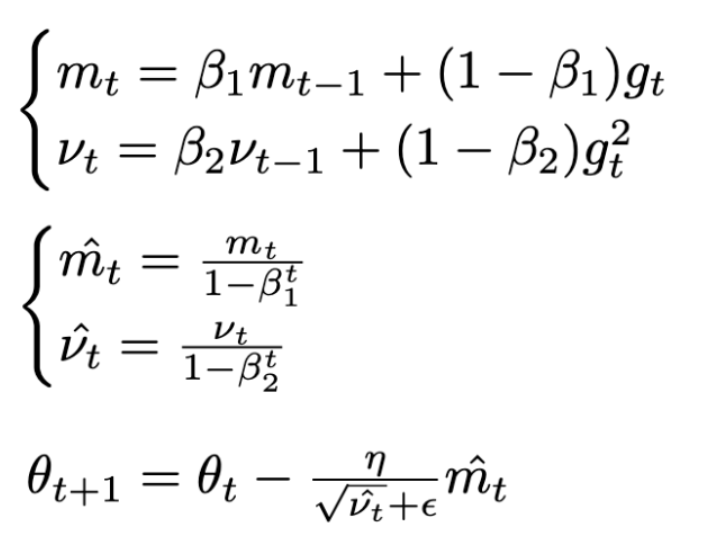

In [ ]:
class Adam(Optimizer):
    def __init__(self, params, lr=1e-3, b1=0.9, b2=0.999, epsilon=1e-8):
        super().__init__(params)
        self.lr = lr
        self.b1 = b1
        self.b2 = b2
        self.epsilon = epsilon
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]
        self.t = 0

    def step(self):
        self.t += 1
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue
                self.m[i] = self.b1 * self.m[i] + (1 - self.b1) * p.grad
                self.v[i] = self.b2 * self.v[i] + (1 - self.b2) * p.grad**2
                m_hat = self.m[i] / (1 - self.b1**self.t)
                v_hat = self.v[i] / (1 - self.b2**self.t)
                p -= self.lr * m_hat / (torch.sqrt(v_hat) + self.epsilon)

###AdamW

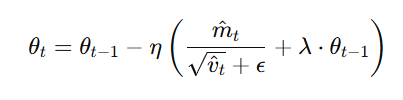

In [ ]:
class AdamW(Optimizer):
    def __init__(self, params, lr=1e-3, b1=0.9, b2=0.999, epsilon=1e-8, weight_decay=1e-2):
        super().__init__(params)
        self.lr = lr
        self.b1 = b1
        self.b2 = b2
        self.epsilon = epsilon
        self.weight_decay = weight_decay
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]
        self.t = 0

    def step(self):
        self.t += 1
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue
                g = p.grad
                self.m[i] = self.b1 * self.m[i] + (1 - self.b1) * g
                self.v[i] = self.b2 * self.v[i] + (1 - self.b2) * (g * g)
                m_hat = self.m[i] / (1 - self.b1 ** self.t)
                v_hat = self.v[i] / (1 - self.b2 ** self.t)
                p -= self.lr * (m_hat / (torch.sqrt(v_hat) + self.epsilon) + self.weight_decay * p)



###Обучаем сверточную нейросеть

In [ ]:
import torch
import torch.nn.functional as F
import torchvision
import os
from torch import nn
from tqdm import tqdm

In [ ]:
transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,))
    ]
)

In [ ]:
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

In [ ]:
seed_everything(42)

mnist_train = torchvision.datasets.MNIST(
    './mnist/',
    train=True,
    download=True,
    transform=transform
)

mnist_val = torchvision.datasets.MNIST(
    './mnist/',
    train=False,
    download=True,
    transform=transform
)

train_dataloader = torch.utils.data.DataLoader(mnist_train, batch_size=64, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(mnist_val, batch_size=64, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 502kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.69MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]


In [ ]:
class Net(nn.Module):
    def __init__(self, kernel1=3, kernel2=3, kernel3=3):
        super(Net, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=kernel1, stride=1, padding=kernel1//2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=kernel2, stride=1, padding=kernel2//2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(64, 128, kernel_size=kernel3, stride=1, padding=kernel3//2),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, 28, 28)
            out = self.conv_layers(dummy)
            flat_size = out.view(1, -1).size(1)

        self.fc_layers = nn.Sequential(
            nn.Linear(flat_size, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = torch.flatten(x, 1)
        x = self.fc_layers(x)
        return F.log_softmax(x, dim=1)

In [ ]:
def test_model(network, test_loader):
    network.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)

            output = network(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)

    return test_loss, accuracy

In [ ]:
def train_and_evaluate(network, optimizer, train_loader, test_loader, num_epochs=10, scheduler=None):
    losses = []
    test_losses = []
    accuracies = []

    for epoch in range(1, num_epochs + 1):
        network.train()
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)

            optimizer.zero_grad()
            output = network(data)
            loss = F.nll_loss(output, target)
            loss.backward()
            optimizer.step()

            if scheduler is not None:
                scheduler.step()

            if batch_idx % 100 == 0:
                print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)} '
                      f'({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {loss.item():.6f}')
                losses.append(loss.item())

        test_loss, accuracy = test_model(network, test_loader)
        test_losses.append(test_loss)
        accuracies.append(accuracy)

        print(f'\nTest set: Average loss: {test_loss:.4f}, Accuracy: {accuracy:.2f}%\n')

    plt.figure(figsize=(12, 10))
    plt.plot(losses, label='Loss')
    plt.title("График изменения лосса")
    plt.xlabel("Batch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

    return losses

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


###Adam

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.305339
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.286652
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.173720
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.061444
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.084940
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.236434
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.124857
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.089614
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.060538
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.010104

Test set: Average loss: 0.0320, Accuracy: 98.87%

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.006561
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.101362
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.005482
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.047631
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.152704
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.219325
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.084447
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.013976
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.033654
Train Epoch

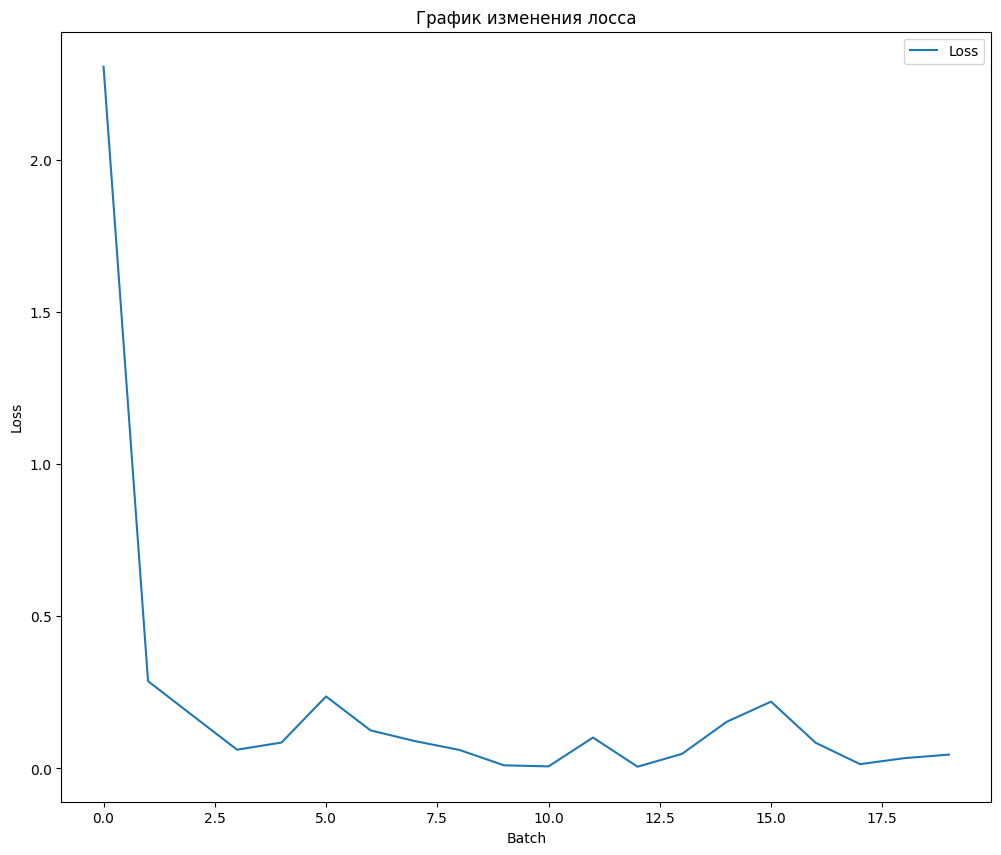

In [ ]:
network = Net().to(device)
optimizer_adam = Adam(network.parameters(), epsilon=1e-8, lr = 1e-3)
adam_loss = train_and_evaluate(network, optimizer_adam, train_dataloader, val_dataloader, num_epochs=2)

###AdamW

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.308923
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.350799
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.103573
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.149222
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.041348
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.087941
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.148452
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.117930
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.085326
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.095023

Test set: Average loss: 0.0481, Accuracy: 98.37%

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.012874
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.023471
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.040510
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.099929
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.067144
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.003301
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.025633
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.030475
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.018357
Train Epoch

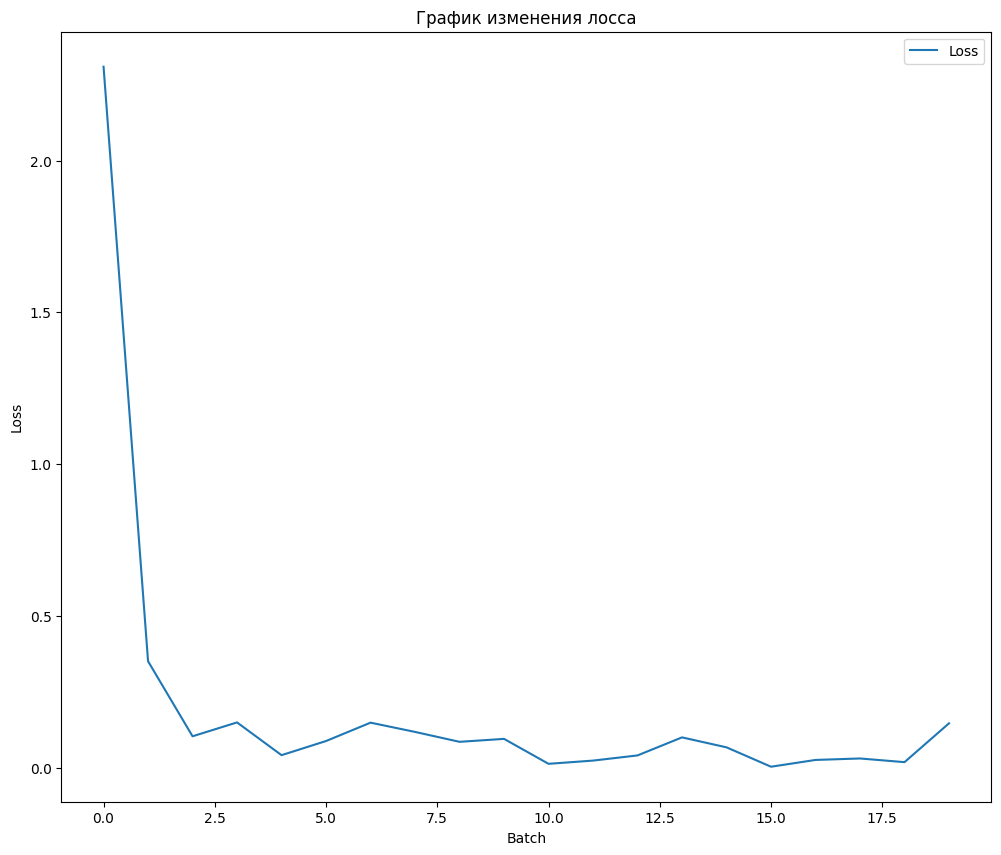

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = Net().to(device)
optimizer_adamW = AdamW(network.parameters(), epsilon=1e-8, lr = 1e-3)
adamW_loss = train_and_evaluate(network, optimizer_adamW, train_dataloader, val_dataloader, num_epochs=2)

###SGD

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.307948
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.291227
Train Epoch: 1 [12800/60000 (21%)]	Loss: 2.283189
Train Epoch: 1 [19200/60000 (32%)]	Loss: 2.266977
Train Epoch: 1 [25600/60000 (43%)]	Loss: 2.224682
Train Epoch: 1 [32000/60000 (53%)]	Loss: 2.087304
Train Epoch: 1 [38400/60000 (64%)]	Loss: 1.470180
Train Epoch: 1 [44800/60000 (75%)]	Loss: 1.089713
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.689717
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.880057

Test set: Average loss: 0.4343, Accuracy: 87.56%

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.649961
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.523176
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.524254
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.393831
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.286289
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.289333
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.283895
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.208810
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.311441
Train Epoch

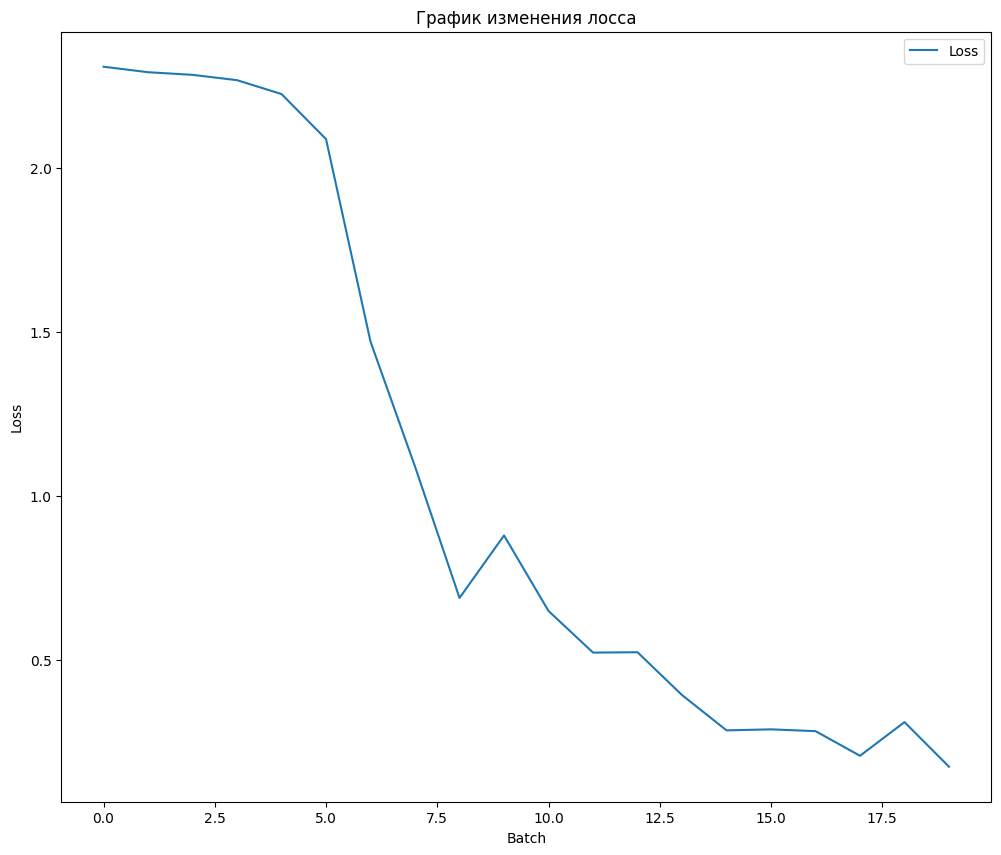

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = Net().to(device)
optimizer_sgd = SGD(network.parameters(), lr = 1e-2)
sgd_loss = train_and_evaluate(network, optimizer_sgd, train_dataloader, val_dataloader, num_epochs=2)

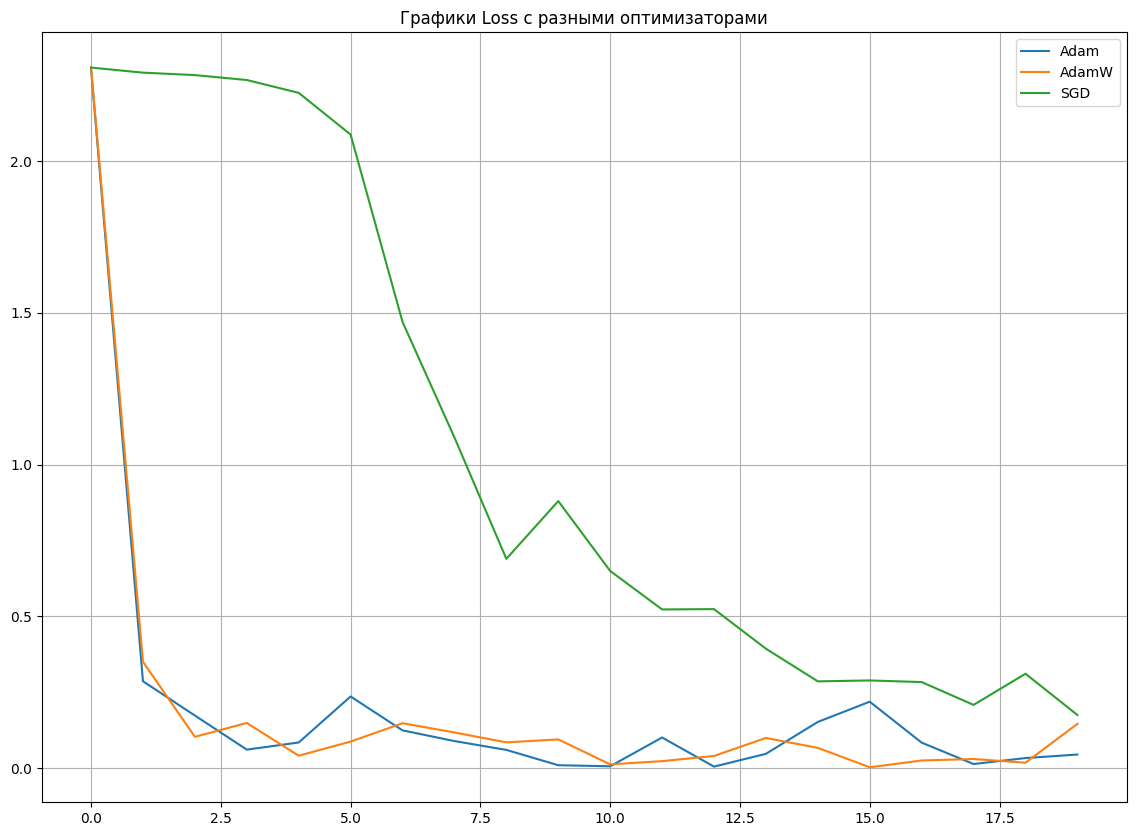

In [ ]:
plt.figure(figsize=(14, 10))
plt.plot(adam_loss, label='Adam')
plt.plot(adamW_loss, label='AdamW')
plt.plot(sgd_loss, label='SGD')
plt.title("Графики Loss с разными оптимизаторами")
plt.legend()
plt.grid()
plt.show()

2. Реализовать LinearLR и CosineAnnealingLR. Обучить сверточную нейросеть на MNIST с SGD, Adam, AdamW с LinearLR, CosineAnnealingLR. Сравните графики изменения loss-функции и точности (суммарно должно быть 9 экспериментов, 3 из которых покрываются пунктом 1).

In [ ]:
import math

In [ ]:
class LRScheduler:
    def __init__(self, optimizer: Optimizer):
        self.optimizer = optimizer
        self.last_iter = 0
        self.base_lr = optimizer.lr

    def get_lr(self):
        raise NotImplementedError()

    def step(self):
        self.last_iter += 1
        lr = self.get_lr()
        self.optimizer.lr = lr
        return lr

In [ ]:
class LinearLR(LRScheduler):
    def __init__(
        self,
        optimizer: Optimizer,
        start_factor: float = 0.1,
        end_factor: float = 1.0,
        total_iters: int = 100
    ):
        super().__init__(optimizer)
        self.start_factor = start_factor
        self.end_factor = end_factor
        self.total_iters = total_iters

    def get_lr(self):
        if self.last_iter >= self.total_iters:
            factor = self.end_factor
        else:
            factor = self.start_factor + (self.end_factor - self.start_factor) * (self.last_iter / self.total_iters)
        return self.base_lr * factor



class CosineAnnealing(LRScheduler):
    def __init__(
            self,
            optimizer: Optimizer,
            T_max: int = 20,
            eta_min: float = 0.01
        ):
        super().__init__(optimizer)
        self.T_max = T_max
        self.eta_min = eta_min

    def get_lr(self):
        return self.eta_min + (self.base_lr - self.eta_min) * (1 + math.cos(math.pi * self.last_iter / self.T_max)) / 2


###Adam + LinearLR

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.303228
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.111578
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.689740
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.170106
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.114092
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.173450
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.067258
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.098286
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.315200
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.071319

Test set: Average loss: 0.0581, Accuracy: 98.17%

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.225754
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.083222
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.294672
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.123448
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.049383
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.128916
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.076407
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.221322
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.018133
Train Epoch

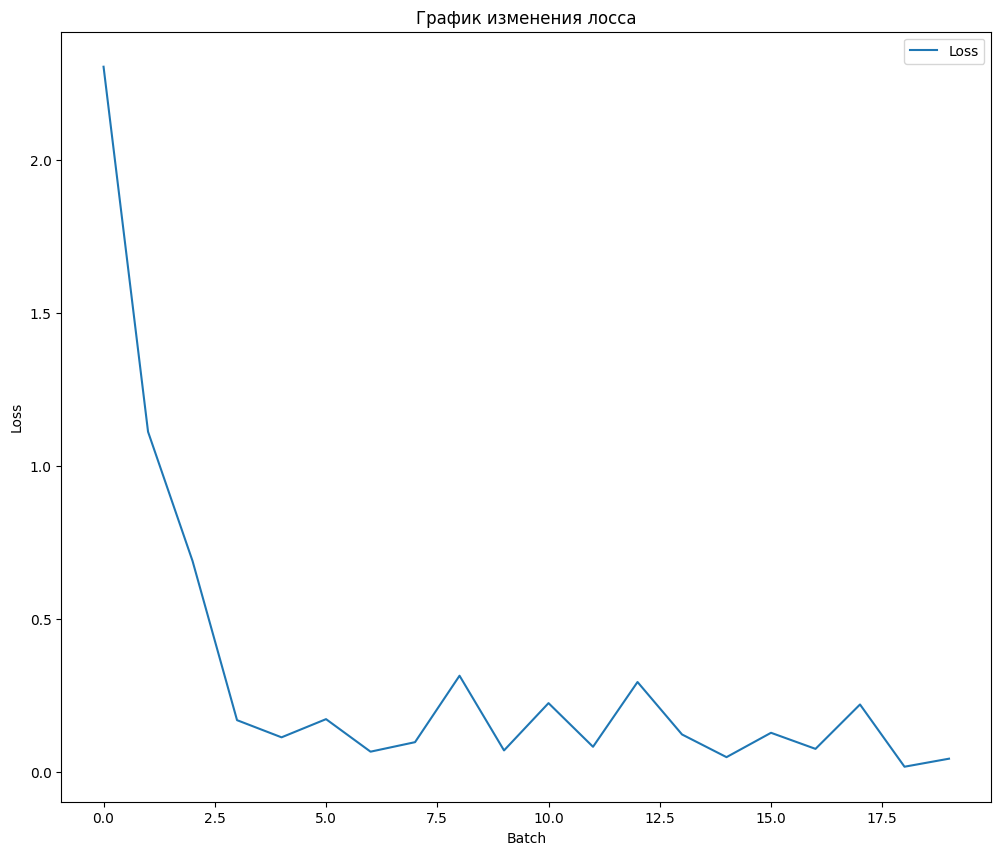

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = Net().to(device)
optimizer_adam = Adam(network.parameters(), lr=1e-3, epsilon=1e-8)
scheduler_adam = LinearLR(optimizer_adam, total_iters=len(train_dataloader)*2)
adam_loss_linearLR = train_and_evaluate(network, optimizer_adam, train_dataloader, val_dataloader, num_epochs=2, scheduler=scheduler_adam)

###AdamW + LinearLR

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.305829
Train Epoch: 1 [6400/60000 (11%)]	Loss: 1.486614
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.350191
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.474288
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.233486
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.376889
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.153582
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.195237
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.115937
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.075067

Test set: Average loss: 0.0591, Accuracy: 98.09%

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.248424
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.157475
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.163394
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.200444
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.057065
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.190951
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.132067
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.026440
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.099990
Train Epoch

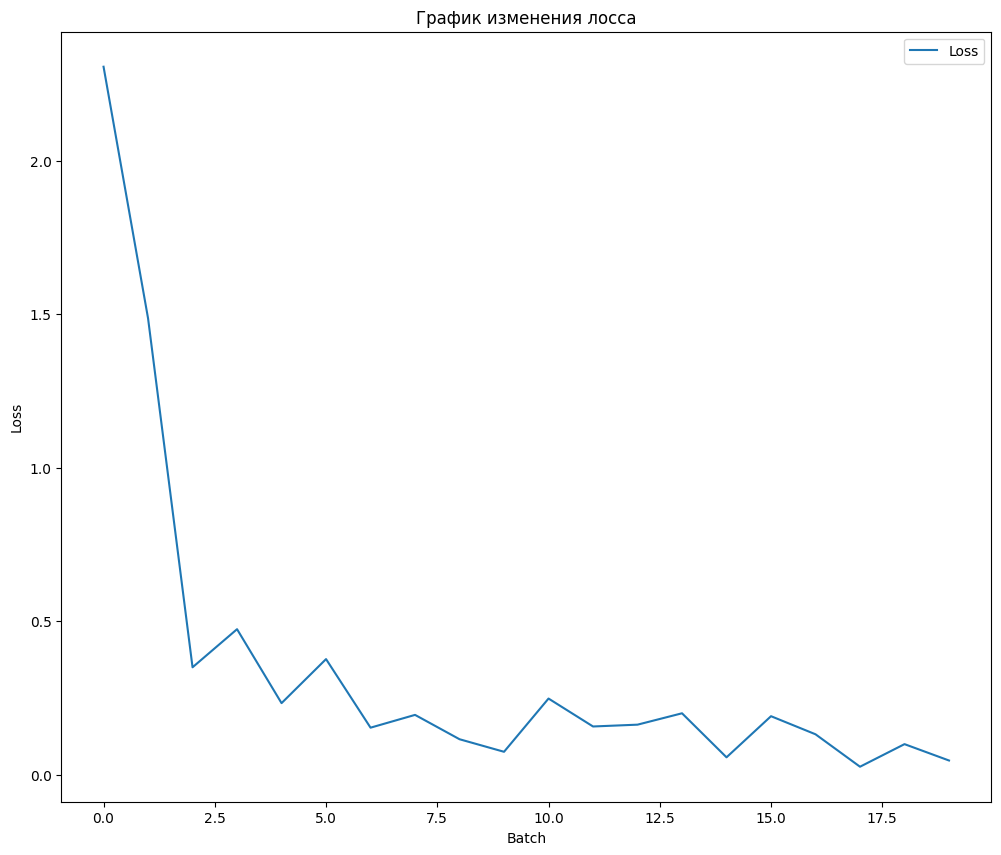

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = Net().to(device)
optimizer_adamW = AdamW(network.parameters(), lr=1e-3, epsilon=1e-8)
scheduler_adamW = LinearLR(optimizer_adamW, total_iters=len(train_dataloader)*2)
adamW_loss_linearLR = train_and_evaluate(network, optimizer_adamW, train_dataloader, val_dataloader, num_epochs=2, scheduler=scheduler_adamW)

###SGD + LinearLR

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.305192
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.303197
Train Epoch: 1 [12800/60000 (21%)]	Loss: 2.308954
Train Epoch: 1 [19200/60000 (32%)]	Loss: 2.302910
Train Epoch: 1 [25600/60000 (43%)]	Loss: 2.301192
Train Epoch: 1 [32000/60000 (53%)]	Loss: 2.300995
Train Epoch: 1 [38400/60000 (64%)]	Loss: 2.293022
Train Epoch: 1 [44800/60000 (75%)]	Loss: 2.291653
Train Epoch: 1 [51200/60000 (85%)]	Loss: 2.280892
Train Epoch: 1 [57600/60000 (96%)]	Loss: 2.281315

Test set: Average loss: 2.2760, Accuracy: 34.23%

Train Epoch: 2 [0/60000 (0%)]	Loss: 2.286476
Train Epoch: 2 [6400/60000 (11%)]	Loss: 2.273202
Train Epoch: 2 [12800/60000 (21%)]	Loss: 2.256683
Train Epoch: 2 [19200/60000 (32%)]	Loss: 2.165865
Train Epoch: 2 [25600/60000 (43%)]	Loss: 2.087038
Train Epoch: 2 [32000/60000 (53%)]	Loss: 1.664062
Train Epoch: 2 [38400/60000 (64%)]	Loss: 1.110604
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.763739
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.724453
Train Epoch

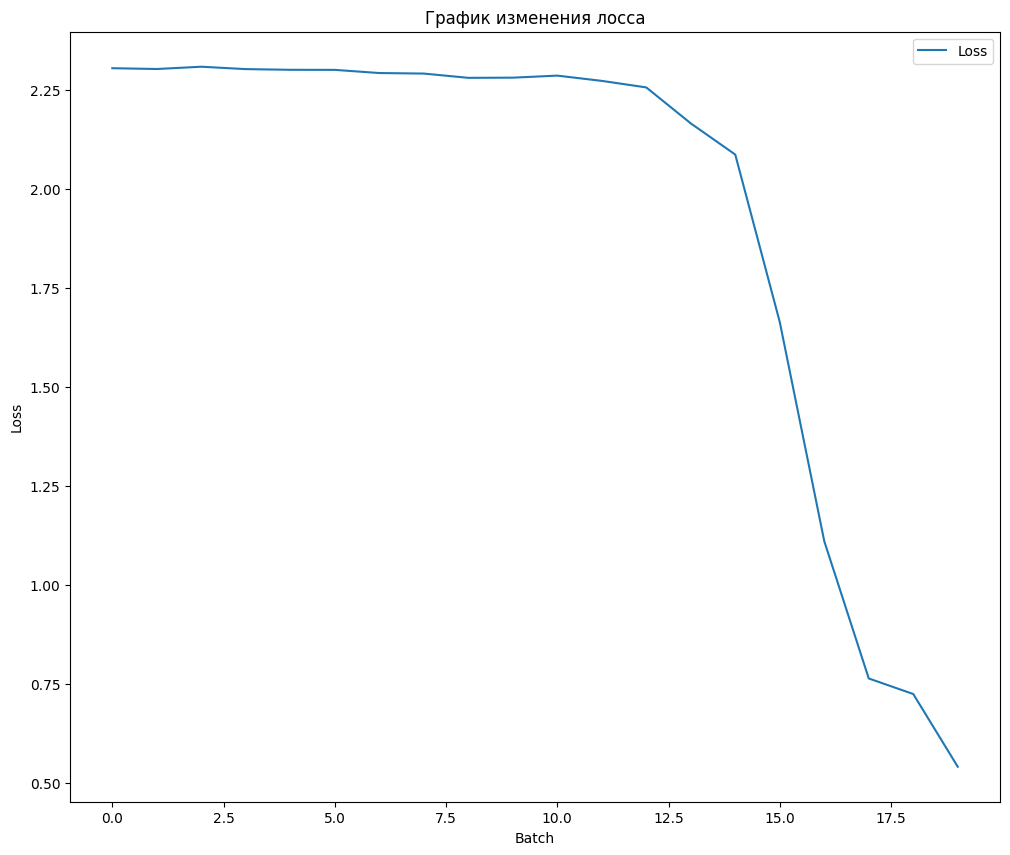

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = Net().to(device)
optimizer_sgd = SGD(network.parameters(), lr = 1e-2)
scheduler_sgd = LinearLR(optimizer_sgd, total_iters=len(train_dataloader)*2)
sgd_loss_linearLR = train_and_evaluate(network, optimizer_sgd, train_dataloader, val_dataloader, num_epochs=2, scheduler=scheduler_sgd)

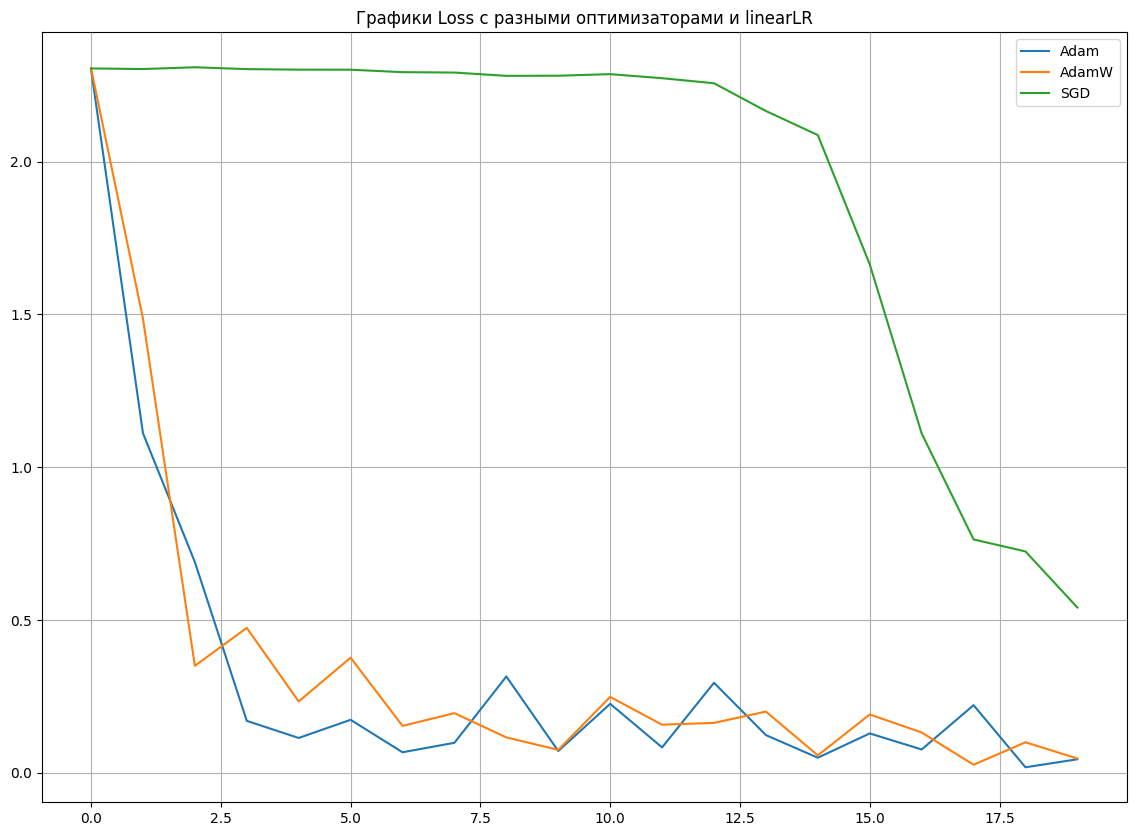

In [ ]:
plt.figure(figsize=(14, 10))
plt.plot(adam_loss_linearLR, label='Adam')
plt.plot(adamW_loss_linearLR, label='AdamW')
plt.plot(sgd_loss_linearLR, label='SGD')
plt.title("Графики Loss с разными оптимизаторами и linearLR")
plt.legend()
plt.grid()
plt.show()

### Adam + CosineAnnealing

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.315561
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.423687
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.045011
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.145305
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.035404
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.037535
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.068503
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.019174
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.007292
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.078587

Test set: Average loss: 0.0927, Accuracy: 97.48%

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.062352
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.116008
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.159845
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.297847
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.095139
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.179992
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.517386
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.719416
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.548882
Train Epoch

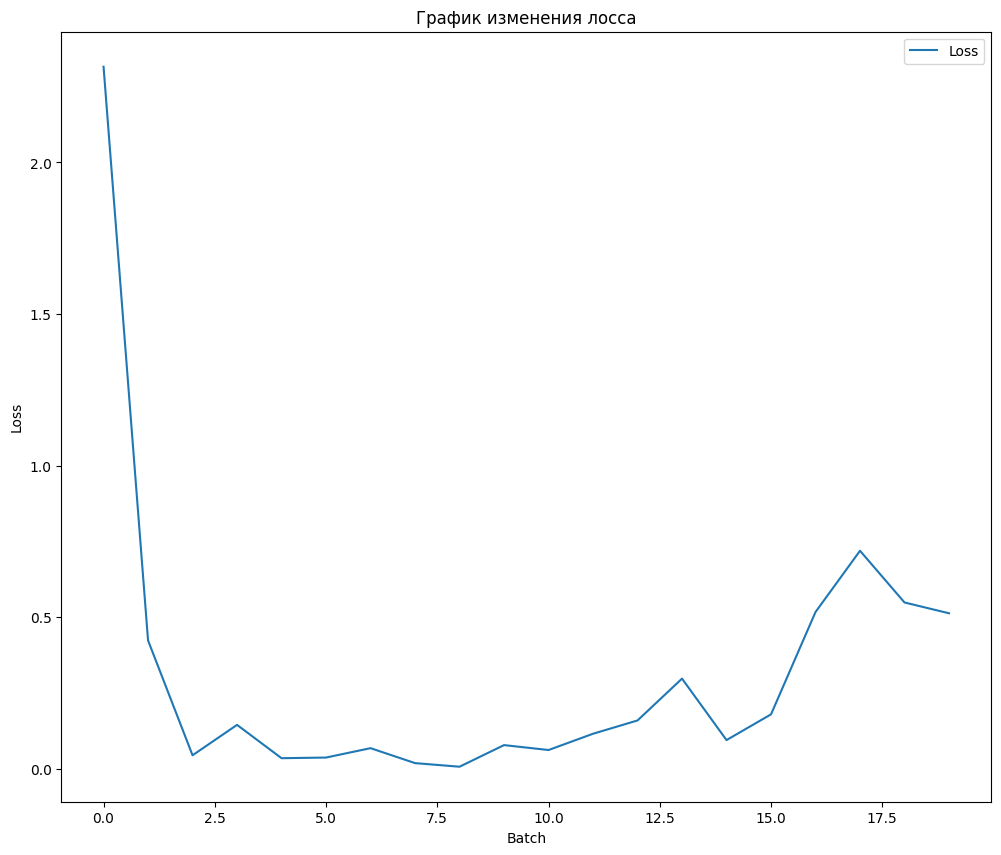

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = Net().to(device)
optimizer_adam = Adam(network.parameters(), lr=1e-3, epsilon=1e-8)
scheduler_adam = CosineAnnealing(optimizer_adam, T_max=len(train_dataloader)*2)
adam_loss_cosineAnnealing = train_and_evaluate(network, optimizer_adam, train_dataloader, val_dataloader, num_epochs=2, scheduler=scheduler_adam)


###AdamW + CosineAnnealing

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.295866
Train Epoch: 1 [6400/60000 (11%)]	Loss: 0.347614
Train Epoch: 1 [12800/60000 (21%)]	Loss: 0.155901
Train Epoch: 1 [19200/60000 (32%)]	Loss: 0.029743
Train Epoch: 1 [25600/60000 (43%)]	Loss: 0.127754
Train Epoch: 1 [32000/60000 (53%)]	Loss: 0.139991
Train Epoch: 1 [38400/60000 (64%)]	Loss: 0.037961
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.189849
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.405230
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.242118

Test set: Average loss: 0.1172, Accuracy: 97.04%

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.319913
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.189939
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.410423
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.224793
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.227193
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.210514
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.995193
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.290374
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.337201
Train Epoch

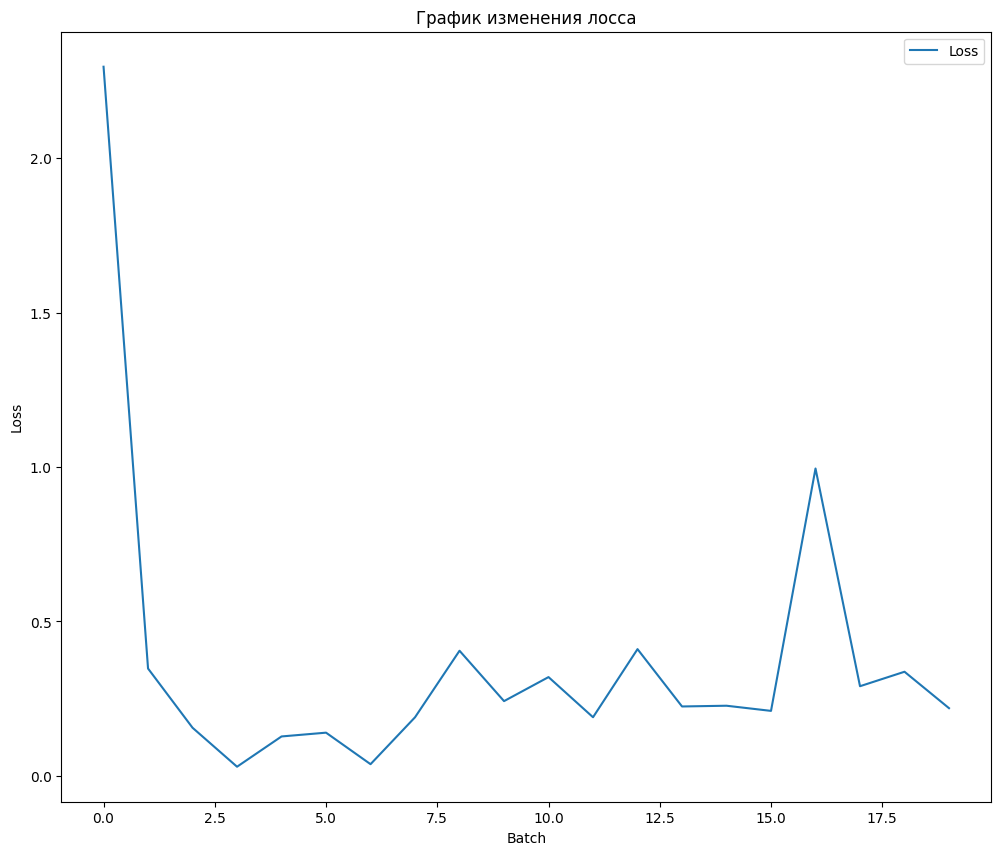

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = Net().to(device)
optimizer_adamW = Adam(network.parameters(), lr=1e-3, epsilon=1e-8)
scheduler_adamW = CosineAnnealing(optimizer_adamW, T_max=len(train_dataloader)*2)
adamW_loss_cosineAnnealing = train_and_evaluate(network, optimizer_adamW, train_dataloader, val_dataloader, num_epochs=2, scheduler=scheduler_adamW)


### SGD + CosineAnnealing

Train Epoch: 1 [0/60000 (0%)]	Loss: 2.300162
Train Epoch: 1 [6400/60000 (11%)]	Loss: 2.290759
Train Epoch: 1 [12800/60000 (21%)]	Loss: 2.262179
Train Epoch: 1 [19200/60000 (32%)]	Loss: 2.203377
Train Epoch: 1 [25600/60000 (43%)]	Loss: 1.873919
Train Epoch: 1 [32000/60000 (53%)]	Loss: 1.315678
Train Epoch: 1 [38400/60000 (64%)]	Loss: 1.040283
Train Epoch: 1 [44800/60000 (75%)]	Loss: 0.879865
Train Epoch: 1 [51200/60000 (85%)]	Loss: 0.559277
Train Epoch: 1 [57600/60000 (96%)]	Loss: 0.583803

Test set: Average loss: 0.3995, Accuracy: 88.17%

Train Epoch: 2 [0/60000 (0%)]	Loss: 0.497089
Train Epoch: 2 [6400/60000 (11%)]	Loss: 0.373756
Train Epoch: 2 [12800/60000 (21%)]	Loss: 0.256372
Train Epoch: 2 [19200/60000 (32%)]	Loss: 0.457165
Train Epoch: 2 [25600/60000 (43%)]	Loss: 0.206233
Train Epoch: 2 [32000/60000 (53%)]	Loss: 0.357588
Train Epoch: 2 [38400/60000 (64%)]	Loss: 0.168170
Train Epoch: 2 [44800/60000 (75%)]	Loss: 0.272207
Train Epoch: 2 [51200/60000 (85%)]	Loss: 0.324788
Train Epoch

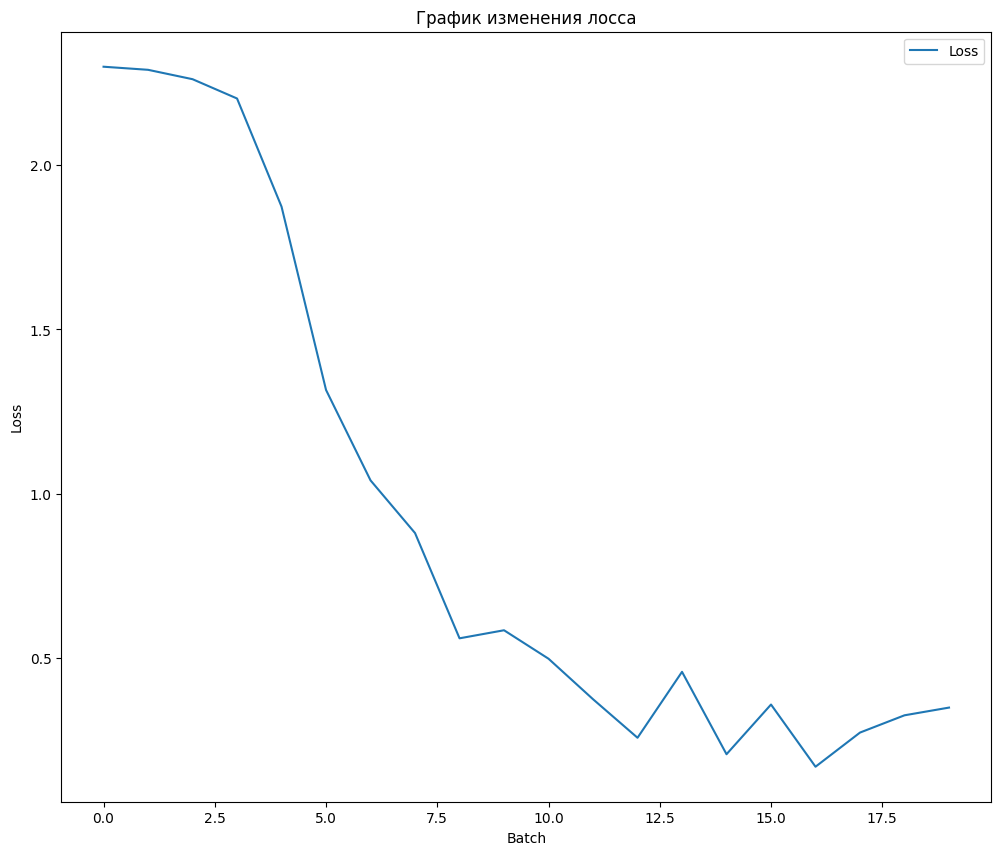

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
network = Net().to(device)
optimizer_sgd = SGD(network.parameters(), lr=1e-2)
scheduler_sgd = CosineAnnealing(optimizer_sgd, T_max=len(train_dataloader)*2)
sgd_loss_cosineAnnealing = train_and_evaluate(network, optimizer_sgd, train_dataloader, val_dataloader, num_epochs=2, scheduler=scheduler_sgd)


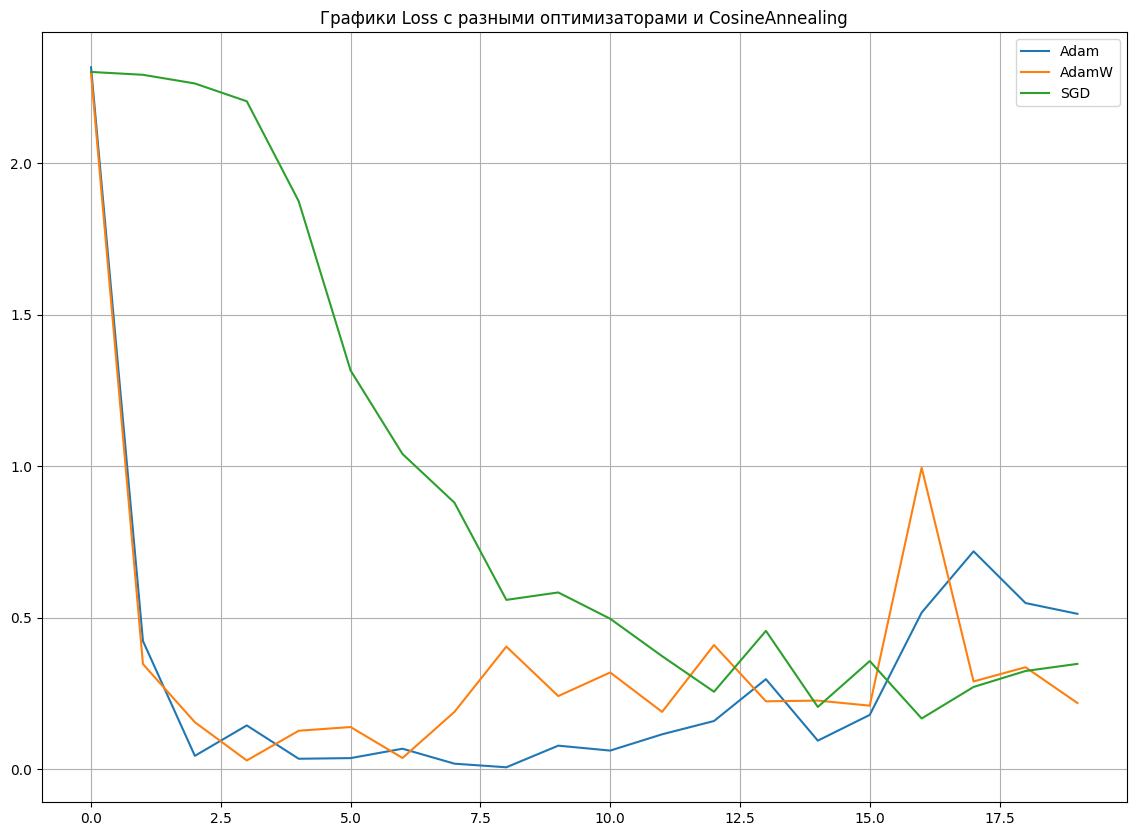

In [ ]:
plt.figure(figsize=(14, 10))
plt.plot(adam_loss_cosineAnnealing, label='Adam')
plt.plot(adamW_loss_cosineAnnealing, label='AdamW')
plt.plot(sgd_loss_cosineAnnealing, label='SGD')
plt.title("Графики Loss с разными оптимизаторами и CosineAnnealing")
plt.legend()
plt.grid()
plt.show()

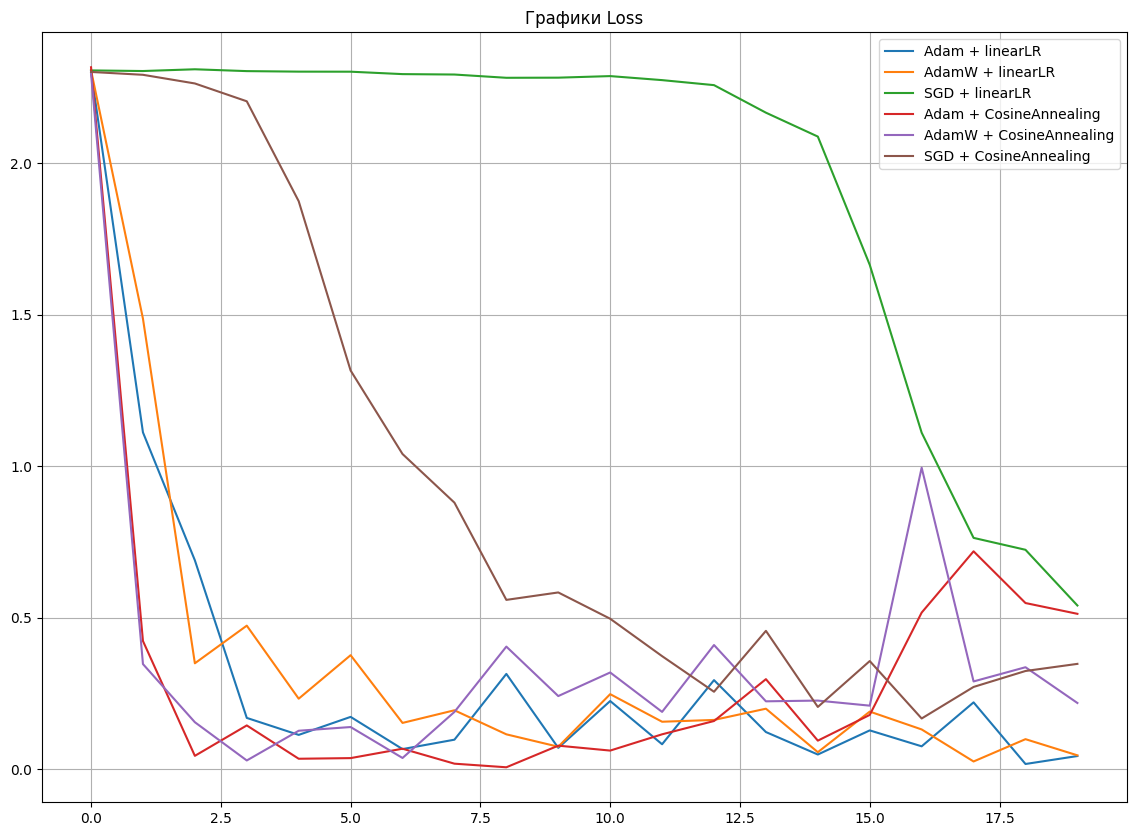

In [ ]:
plt.figure(figsize=(14, 10))
plt.plot(adam_loss_linearLR, label='Adam + linearLR')
plt.plot(adamW_loss_linearLR, label='AdamW + linearLR')
plt.plot(sgd_loss_linearLR, label='SGD + linearLR')
plt.plot(adam_loss_cosineAnnealing, label='Adam + CosineAnnealing')
plt.plot(adamW_loss_cosineAnnealing, label='AdamW + CosineAnnealing')
plt.plot(sgd_loss_cosineAnnealing, label='SGD + CosineAnnealing')
plt.title("Графики Loss")
plt.legend()
plt.grid()
plt.show()

| № | Оптимизатор | LR Scheduler    | Accuracy (эпоха 2) |
| - | ----------- | --------------- | ------------------ |
| 1 | Adam        | —               | **99.05%**         |
| 2 | AdamW       | —               | 98.90%             |
| 3 | SGD         | —               | 95.40%             |
| 4 | Adam        | LinearLR        | 98.48%             |
| 5 | AdamW       | LinearLR        | 98.57%             |
| 6 | SGD         | LinearLR        | 87.68%             |
| 7 | Adam        | CosineAnnealing | 94.95%             |
| 8 | AdamW       | CosineAnnealing | 95.86%             |
| 9 | SGD         | CosineAnnealing | 95.47%             |


##**Выводы:**

1. Adam без шедулеров показал лучший результат (99.05%).

2. AdamW также стабильно обучался, но немного хуже (98.9%).

3. SGD без шедулеров обучается заметно медленнее (только 95.4% после 2 эпох).

4. LinearLR хорошо работает для Adam/AdamW, но сильно ухудшил результат у SGD (87.7%).
    - Возможно, линейное изменение lr было слишком резким для SGD.

5. CosineAnnealing дал нестабильные результаты у Adam/AdamW (сильные скачки loss во 2-й эпохе).

    - Итоговая точность снизилась до 94–96%.

6. Для SGD + CosineAnnealing результат улучшился по сравнению с базовым SGD (до 95.47%).





#### Feedback (опционально)

Здесь вы можете оставить список опечаток из лекции или семинара:

- Your text here

Здесь вы можете оставить комментарии по лекции или семинару:

- Your text here